# Levels of fidelity

> The same links simulated at every level, from an analytic formula to every bit of 5G NR: how far apart they are, and what each costs.

A 392-bit message (49 codebook indices of 8 bits) over a flat channel, at SNRs from −4 to 12 dB, at each level:

| level | what it does |
|---|---|
| analytic | `packet_error_rate`: uncoded BPSK, independent bit errors |
| `SystemLevelChannel` | draws losses from that rate |
| `LinkLevelChannel` (with a CRC) | simulates every bit, uncoded BPSK |
| `SionnaErrorModel` | 5G NR with LDPC codes, from Sionna SYS's tables (MCS 3 and 9) |
| `SionnaLinkChannel` | every bit of 5G NR with Sionna PHY, at the same MCSs |

The Sionna rows need Sionna 2 (`pip install 'comm-core[sionna]'`). Their cells are flagged `#| sionna`, and their
saved output is shown.

In [ ]:
import math

import matplotlib.pyplot as plt
import numpy as np

from comm_core import *

In [ ]:
import time

In [ ]:
SNRS = np.arange(-4, 12.5, 1.0)
INDICES = np.arange(49) * 5
N = 300

def pairs(n, payload=INDICES, size_bits=392):
    return [(Transmission(Message('a', 'b', payload, size_bits=size_bits), 'a', 'b', 0.0), Link('a', 'b')) for _ in range(n)]

def loss(channel, n=N):
    t0 = time.perf_counter()
    rs = channel.transmit_batch(pairs(n)) if hasattr(channel, 'transmit_batch') else [channel.transmit(*p) for p in pairs(n)]
    return 1 - np.mean([r.success for r in rs]), (time.perf_counter() - t0) / n

curves, cost = {}, {}
curves['analytic (uncoded BPSK)'] = [packet_error_rate(s, 392) for s in SNRS]
out = [loss(SystemLevelChannel(noise_power=10 ** (-s / 10), seed=0)) for s in SNRS]
curves['SystemLevelChannel'], cost['SystemLevelChannel'] = [o[0] for o in out], np.mean([o[1] for o in out])
out = [loss(LinkLevelChannel(noise_power=10 ** (-s / 10), drop_corrupted=True, seed=0)) for s in SNRS]
curves['LinkLevelChannel'], cost['LinkLevelChannel'] = [o[0] for o in out], np.mean([o[1] for o in out])

In [ ]:
#| sionna
for mcs in (3, 9):
    model = SionnaErrorModel(mcs_index=mcs)
    t0 = time.perf_counter()
    curves[f'SionnaErrorModel, MCS {mcs}'] = list(model([np.array([10 ** (s / 10)]) for s in SNRS], np.full(len(SNRS), 392))[0])
    cost['SionnaErrorModel'] = (time.perf_counter() - t0) / len(SNRS)
    out = [loss(SionnaLinkChannel(noise_power=10 ** (-s / 10), mcs_index=mcs, num_bp_iter=50, seed=0), n=150) for s in SNRS]
    curves[f'SionnaLinkChannel, MCS {mcs}'], cost['SionnaLinkChannel'] = [o[0] for o in out], np.mean([o[1] for o in out])

time per message: {'SystemLevelChannel': '0.024 ms', 'LinkLevelChannel': '0.083 ms', 'SionnaErrorModel': '0.308 ms', 'SionnaLinkChannel': '15.022 ms'}


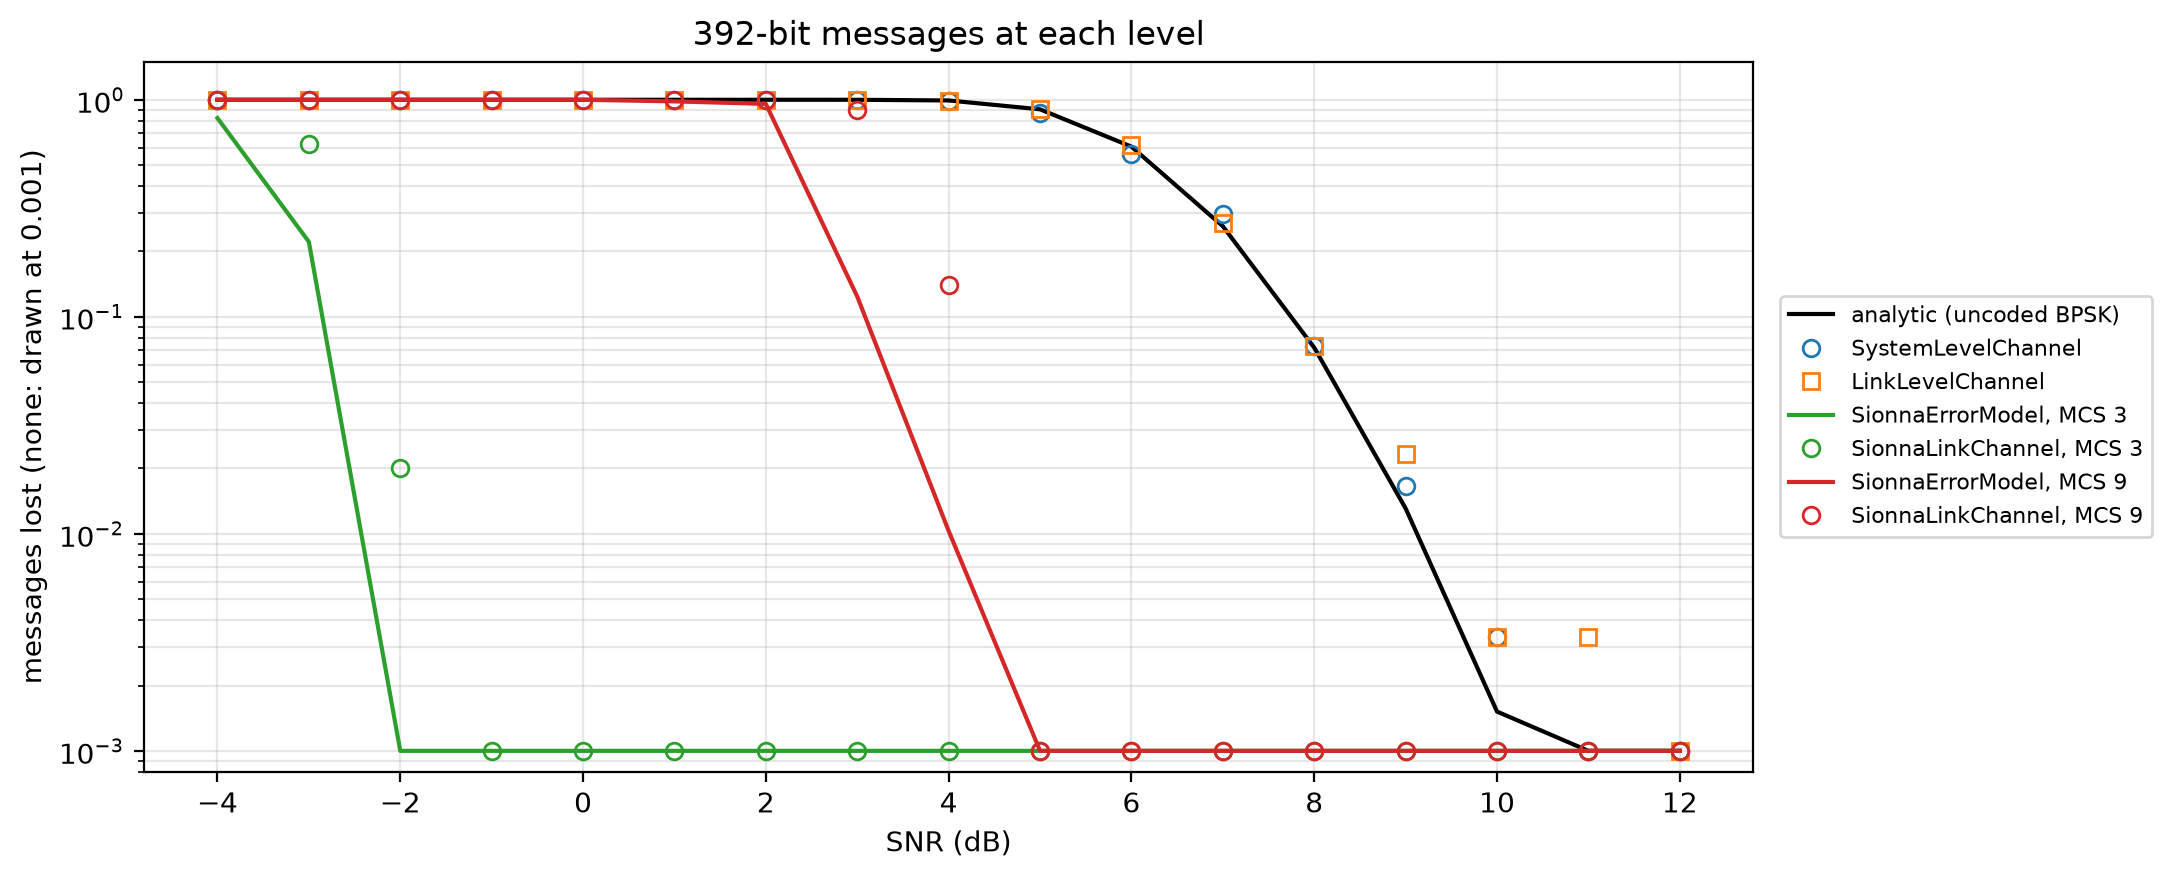

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4.5))
styles = {'analytic': ('k', '-'), 'SystemLevelChannel': ('C0', 'o'), 'LinkLevelChannel': ('C1', 's'),
          'SionnaErrorModel, MCS 3': ('C2', '-'), 'SionnaLinkChannel, MCS 3': ('C2', 'o'),
          'SionnaErrorModel, MCS 9': ('C3', '-'), 'SionnaLinkChannel, MCS 9': ('C3', 'o')}
for name, y in curves.items():
    color, style = next((v for k, v in styles.items() if name.startswith(k)), ('C4', '-'))
    y = np.maximum(np.array(y, float), 1e-3)
    if style == '-':
        ax.plot(SNRS, y, color=color, label=name)
    else:
        ax.plot(SNRS, y, style, color=color, mfc='none', label=name)
ax.set(yscale='log', ylim=(8e-4, 1.5), xlabel='SNR (dB)', ylabel='messages lost (none: drawn at 0.001)', title='392-bit messages at each level')
ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=8, loc='center left', bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()
print('time per message:', {k: f'{1e3 * v:.3f} ms' for k, v in cost.items()})

* **Uncoded levels agree.** The system level follows the analytic rate, and the bit-level simulation follows it
  too (lines and markers of the same colour).
* **Coding moves the curves.** With 5G NR's LDPC codes, a message survives at SNRs where uncoded BPSK loses
  everything: MCS 3 from about −2 dB. Lower MCSs are more robust, higher ones faster. (MCS 0–2, with code rates
  below 1/5, are not available at the link level: Sionna's LDPC encoder doesn't support them.)
* **Sionna SYS against Sionna PHY.** The tables (lines) and the bit-level simulation (markers) agree within about
  a dB at these MCSs. The bit level is 0.5–1 dB worse.
* **Cost.** Each level costs more, up to tens of milliseconds per message for every bit of 5G NR on a CPU. That's
  why training runs at the system level and the link level is for checking.

In [ ]:
assert np.allclose(curves['SystemLevelChannel'], curves['analytic (uncoded BPSK)'], atol=0.1)
assert np.allclose(curves['LinkLevelChannel'], curves['analytic (uncoded BPSK)'], atol=0.1)